# Exe3

## Problem 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sigmoid = lambda z: 1 / (1 + np.exp(-z))

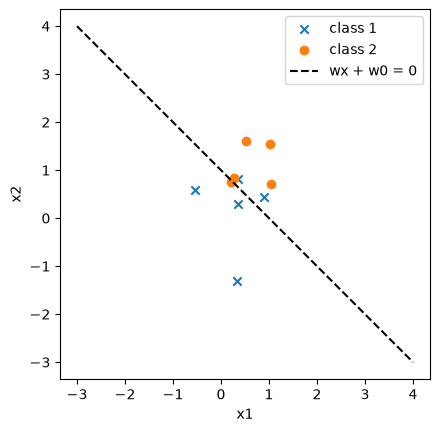

accuracy: 0.7


In [ ]:
# 1a - two Gaussian classes, one good linear boundary
rng = np.random.default_rng(1)
X1 = rng.multivariate_normal([0, 0], np.eye(2), 5)  # class 1  (target 0)
X2 = rng.multivariate_normal([1, 1], np.eye(2), 5)  # class 2  (target 1)

# boundary perpendicular to (mu2 - mu1) = [1,1] through the midpoint [.5,.5]  ->  x1 + x2 - 1 = 0
w, w0 = np.array([1.0, 1.0]), -1.0

xs = np.array([-3.0, 4.0])
plt.scatter(*X1.T, marker="x", label="class 1")
plt.scatter(*X2.T, marker="o", label="class 2")
plt.plot(xs, -(w[0] * xs + w0) / w[1], "k--", label="wx + w0 = 0")
plt.gca().set_aspect("equal"); plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.show()

acc = (np.sum(X1 @ w + w0 < 0) + np.sum(X2 @ w + w0 > 0)) / 10   # sign of wx+w0 = predicted class
print("accuracy:", acc)

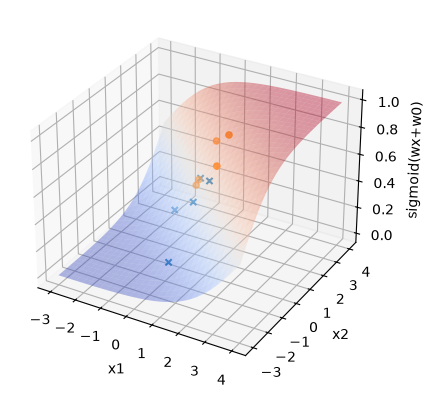

class 1  sigma: [0.54 0.12 0.59 0.28 0.42]
class 2  sigma: [0.83 0.53 0.75 0.68 0.49]


In [3]:
# 1b - z-axis = sigmoid(wx + w0);  the boundary sits at z = 0.5
g = np.linspace(-3, 4, 60)
XX, YY = np.meshgrid(g, g)
ZZ = sigmoid(w[0] * XX + w[1] * YY + w0)

ax = plt.figure().add_subplot(projection="3d")
ax.plot_surface(XX, YY, ZZ, alpha=0.4, cmap="coolwarm")
ax.scatter(*X1.T, sigmoid(X1 @ w + w0), marker="x")   # class 1 -> pushed toward 0
ax.scatter(*X2.T, sigmoid(X2 @ w + w0), marker="o")   # class 2 -> pushed toward 1
ax.set(xlabel="x1", ylabel="x2", zlabel="sigmoid(wx+w0)"); plt.show()

print("class 1  sigma:", np.round(sigmoid(X1 @ w + w0), 2))
print("class 2  sigma:", np.round(sigmoid(X2 @ w + w0), 2))

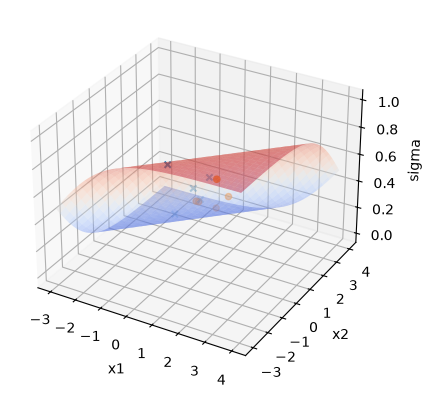

accuracy (bad boundary): 0.3


In [4]:
# 1c - ineffective boundary x1 = x2: it runs through BOTH class centres
wb, wb0 = np.array([1.0, -1.0]), 0.0

ZZb = sigmoid(wb[0] * XX + wb[1] * YY + wb0)
ax = plt.figure().add_subplot(projection="3d")
ax.plot_surface(XX, YY, ZZb, alpha=0.4, cmap="coolwarm")
ax.scatter(*X1.T, sigmoid(X1 @ wb + wb0), marker="x")
ax.scatter(*X2.T, sigmoid(X2 @ wb + wb0), marker="o")
ax.set(xlabel="x1", ylabel="x2", zlabel="sigma"); plt.show()

acc_bad = (np.sum(X1 @ wb + wb0 < 0) + np.sum(X2 @ wb + wb0 > 0)) / 10
print("accuracy (bad boundary):", acc_bad)   # both classes' sigma collapse around 0.5

In [5]:
# 1d - mean cross-entropy  L = -mean[ y*log(yhat) + (1-y)*log(1-yhat) ]   (class 2 = positive)
def ce(w, w0):
    p1, p2 = sigmoid(X1 @ w + w0), sigmoid(X2 @ w + w0)
    return -np.mean(np.r_[np.log1p(-p1), np.log(p2)])   # class 1: y=0 -> log(1-p);  class 2: y=1 -> log(p)

print(f"good boundary (1b) : acc {acc:.1f}   CE {ce(w, w0):.3f}")
print(f"bad  boundary (1c) : acc {acc_bad:.1f}   CE {ce(wb, wb0):.3f}")
print(f"reference, all yhat = 0.5   : CE {-np.log(0.5):.3f}")

good boundary (1b) : acc 0.7   CE 0.487
bad  boundary (1c) : acc 0.3   CE 0.917
reference, all yhat = 0.5   : CE 0.693


### (1d) Choice of the loss function

**The appropriate loss is the cross-entropy (log loss), not the squared error.**

#### What the visualizations show

- **(1b), effective boundary:** the sigmoid outputs of the two classes *separate* — class 1 is pushed toward 0, class 2 toward 1 (apart from points that genuinely lie in the overlap region). The model is confident *and* correct.
- **(1c), ineffective boundary:** the outputs of both classes *collapse around 0.5*. The model is maximally uncertain and cannot tell the classes apart.

A good loss must be small in case (1b), large in case (1c), and its gradient must drive the parameters from (1c) toward (1b).

#### Why not the squared error $E = \sum_i \big(y_i - \sigma(z_i)\big)^2$

1. **Non-convex** in $w$ once the sigmoid is inside, so gradient descent can get stuck in local minima.
2. **Vanishing gradient under saturation.** Where $|z|$ is large, $\sigma'(z) = \sigma(z)\big(1-\sigma(z)\big) \approx 0$, so $\partial E/\partial w \approx 0$ *even for a confidently wrong prediction* — the gradient disappears exactly when the strongest correction is needed.
3. **Bounded penalty.** The worst case ($y=1$, $\hat y = 0$) contributes only $1$; it does not distinguish "wrong and unsure" from "wrong and certain".

#### Why the cross-entropy $L = -\sum_i \big[\, y_i \ln \hat y_i + (1-y_i)\ln(1-\hat y_i)\,\big]$

1. **Convex** in $w$ for logistic regression → a single global minimum, gradient descent converges.
2. **Unbounded penalty for confident mistakes:** $y=1,\ \hat y \to 0 \Rightarrow -\ln \hat y \to +\infty$. It punishes precisely the failure mode seen with a bad boundary.
3. **Maximum-likelihood interpretation:** $P(\text{labels}) = \prod_i \hat y_i^{\,y_i}(1-\hat y_i)^{1-y_i}$, and $L = -\ln P(\text{labels})$. Minimizing $L$ = maximizing the probability the model assigns to the observed labels.
4. **Informative gradient:** $\partial L/\partial w = X^\top(\hat y - y)$, proportional to the error $(\hat y - y)$ and not killed by saturation.

#### Numerical comparison (this run)

| boundary | accuracy | cross-entropy (avg per point) |
|---|---|---|
| effective (1b)   | 0.7 | 0.487 |
| ineffective (1c) | 0.3 | 0.917 |
| reference: all outputs = 0.5 | 0.5 | 0.693 |

The ineffective boundary has a cross-entropy **worse than the chance level** (0.917 > 0.693): several points are confidently on the wrong side, and the loss registers it. Accuracy only reports 0.3 vs 0.5 and misses *how badly* the model fails.

#### Why not just train on accuracy

Accuracy is a step function of the parameters: its gradient is zero almost everywhere and undefined at the decision boundary, so it cannot be optimized by gradient descent. The cross-entropy is the smooth, convex, differentiable surrogate that also encodes *how confident and how correct* each prediction is.

### (1e) Relation between the single neuron and logistic regression

The figure shows a **perceptron**: inputs $x_j$, weights $w_j$, weighted sum
$z=\sum_j x_j w_j$, a **step activation**, and a hard output $y=\mathbb{1}[z>0]$.

**Logistic regression is the same neuron with the step replaced by the sigmoid:**

| | perceptron (figure) | logistic regression |
|---|---|---|
| weighted sum | $z=\sum_j x_j w_j$ | $z = w^\top x + w_0$ (bias $w_0$ = weight on a constant input $1$) |
| activation | step $\;\mathbb{1}[z>0]$ | sigmoid $\;\sigma(z)=\dfrac{1}{1+e^{-z}}$ |
| output | hard label $\{0,1\}$ | probability $\hat y = P(C_1\mid x)\in(0,1)$ |
| training | perceptron rule | minimize cross-entropy by gradient descent |

Why the change matters:

- The step is discontinuous and has zero derivative almost everywhere, so it
  cannot be trained by gradient descent and gives no measure of confidence.
- The sigmoid is smooth, with $\sigma'(z)=\sigma(z)(1-\sigma(z))$, so the output
  is differentiable in $w$ and can be read as a class probability. It is the
  "soft" version of the step: $\sigma(z)\to\mathbb{1}[z>0]$ as $\lVert w\rVert\to\infty$.

In both cases the decision boundary is the hyperplane $z=0$, so a single unit
only separates (approximately) linearly separable classes. Stacking such units
in layers with non-linear activations yields a neural network capable of
non-linear boundaries; logistic regression is the basic building block.

## Problem 2

In [ ]:
# 2a - vectorised logistic discrimination (batch gradient descent on the cross-entropy)
def train_logreg(X, y, eta=0.5, epochs=5000):
    Xb = np.c_[np.ones(len(X)), X]  # prepend a 1-column -> bias is w[0]
    w = np.zeros(Xb.shape[1])
    for _ in range(epochs):
        w -= eta * Xb.T @ (sigmoid(Xb @ w) - y) / len(y)  # dL/dw = X.T @ (yhat - y) / N  (all weights at once)
    return w

def predict(X, w):
    return (sigmoid(np.c_[np.ones(len(X)), X] @ w) >= 0.5).astype(int)

In [ ]:
# 2b - tic-tac-toe end games: col 0 = label (1 if X won), cols 1-9 = board in {1,-1,0}
df = pd.read_csv("tictac-end.csv")
y = df["label"].to_numpy()
X = df.drop(columns="label").to_numpy(float)

i = np.random.default_rng(0).permutation(len(y))
tr, te = np.split(i, [int(0.7 * len(y))])  # 70 / 30 split

w = train_logreg(X[tr], y[tr])
pred, yt = predict(X[te], w), y[te]

TP = np.sum((pred == 1) & (yt == 1)); TN = np.sum((pred == 0) & (yt == 0))
FP = np.sum((pred == 1) & (yt == 0)); FN = np.sum((pred == 0) & (yt == 1))
print(f"confusion matrix   [[TN {TN}  FP {FP}]\n                    [FN {FN}  TP {TP}]]")
print("accuracy:", (TP + TN) / len(te))

confusion matrix   [[TN 97  FP 5]
                    [FN 0  TP 186]]
accuracy: 0.9826388888888888


## Problem 3

### (3a) Gradient of the scalar product

**Claim.** For $x, a \in \mathbb{R}^N$,  $\dfrac{\partial}{\partial a}(x^\top a) = x$,
and by symmetry $\dfrac{\partial}{\partial a}(a^\top x) = x$.

**Proof.** The scalar product is a scalar,
$$x^\top a = \sum_{j=1}^N x_j a_j .$$
Its $k$-th partial derivative with respect to $a$ is
$$\frac{\partial}{\partial a_k}\sum_{j=1}^N x_j a_j
 = \sum_{j=1}^N x_j \frac{\partial a_j}{\partial a_k}
 = \sum_{j=1}^N x_j \,\delta_{jk} = x_k ,$$
since the components of $a$ are independent ($\partial a_j/\partial a_k = \delta_{jk}$)
and $x$ does not depend on $a$. Stacking over $k = 1,\dots,N$ gives
$$\frac{\partial}{\partial a}(x^\top a) = [x_1,\dots,x_N]^\top = x. \qquad\blacksquare$$

For the second equality, $x^\top a$ is a scalar so $x^\top a = a^\top x$; it is the
same function of $a$, hence $\dfrac{\partial}{\partial a}(a^\top x) = x$.

**Relevance.** This is the basic step behind the loss gradient: in logistic
regression the pre-activation $z = w^\top x$ is linear in $w$ with
$\partial z/\partial w = x$, which combined with the chain rule and
$\sigma'(z) = \sigma(z)(1-\sigma(z))$ yields $\partial L/\partial w = X^\top(\hat y - y)$.

# Problem 4 — Evaluation metrics (ROC / AUC in closed form)

A classifier predicts the **positive** class when $\hat P(C_1\mid x) > \theta$, with a
threshold $0 < \theta < 1$. As functions of $\theta$ we are given

$$f_p(\theta) = N\cos\!\Big(\tfrac{\pi\theta}{2}\Big),
\qquad
t_p(\theta) = T\cos\!\Big(\tfrac{\pi\theta}{2}\Big)\Big(2-\cos\!\Big(\tfrac{\pi\theta}{2}\Big)\Big),$$

where $N$ is the number of negative samples and $T$ the number of positive samples.

### (4a) True positive rate and false positive rate

From the slide definitions (L4, slide 9)

$$\mathrm{TPR}=\frac{TP}{P}=\frac{TP}{TP+FN}=1-\mathrm{FNR},
\qquad
\mathrm{FPR}=\frac{FP}{N}=\frac{FP}{FP+TN}=1-\mathrm{TNR}.$$

The positive count is $P\equiv T$ and the negative count is $N$, so dividing the two
given models by their totals:

$$\boxed{\;\mathrm{FPR}(\theta)=\dfrac{f_p}{N}=\cos\!\Big(\tfrac{\pi\theta}{2}\Big)\;}$$

$$\boxed{\;\mathrm{TPR}(\theta)=\dfrac{t_p}{T}=\cos\!\Big(\tfrac{\pi\theta}{2}\Big)\Big(2-\cos\!\Big(\tfrac{\pi\theta}{2}\Big)\Big)\;}$$

**Check at the extremes** (the threshold sweeps the whole curve):

| $\theta$ | $\cos(\pi\theta/2)$ | FPR | TPR | meaning |
|---|---|---|---|---|
| $\theta\to 0^+$ | $1$ | $1$ | $1\cdot(2-1)=1$ | threshold $\approx 0$: everything called positive $\Rightarrow (1,1)$ |
| $\theta\to 1^-$ | $0$ | $0$ | $0$ | threshold $\approx 1$: nothing called positive $\Rightarrow (0,0)$ |

Both rates fall monotonically as $\theta$ grows, i.e. as the classifier becomes stricter.

### (4b) ROC curve

The ROC curve is $\mathrm{TPR}$ versus $\mathrm{FPR}$ while $\theta$ sweeps $(0,1)$.
Following the hint, write everything through

$$u \;=\; \cos\!\Big(\tfrac{\pi\theta}{2}\Big) \;=\; \mathrm{FPR},
\qquad u\in[0,1]$$

(as $\theta$ runs $1\to 0$, $u$ runs $0\to 1$). Then

$$\boxed{\;\mathrm{TPR} \;=\; u\,(2-u) \;=\; 2u-u^{2} \;=\; 2\,\mathrm{FPR}-\mathrm{FPR}^{2}\;}$$

so the ROC is an **arc of a downward parabola** joining $(0,0)$ to $(1,1)$:

- $\dfrac{d\,\mathrm{TPR}}{d\,\mathrm{FPR}} = 2-2u \ge 0$ on $[0,1]$ — monotone increasing,
  slope $2$ at the origin, slope $0$ at $(1,1)$;
- $\dfrac{d^{2}\,\mathrm{TPR}}{d\,\mathrm{FPR}^{2}} = -2 < 0$ — concave, so the curve
  **bows above the diagonal** $\mathrm{TPR}=\mathrm{FPR}$ (a classifier better than random).
  For instance at $\mathrm{FPR}=0.5$: $\mathrm{TPR}=1-0.25=0.75$.

### (4c) AUC

$$\mathrm{AUC}
=\int_{0}^{1}\mathrm{TPR}\;d(\mathrm{FPR})
=\int_{0}^{1}\big(2u-u^{2}\big)\,du
=\Big[\,u^{2}-\tfrac{u^{3}}{3}\,\Big]_{0}^{1}
=1-\tfrac{1}{3}
=\boxed{\tfrac{2}{3}\approx 0.667}.$$

Better than a random classifier ($\mathrm{AUC}=0.5$, the diagonal) but far from a perfect
one ($\mathrm{AUC}=1$, the top-left corner).

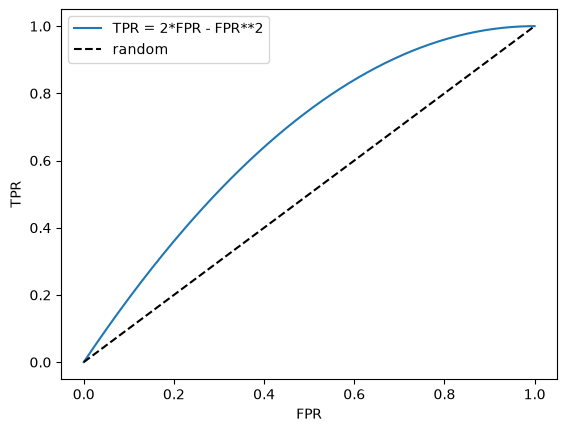

AUC = 0.6666624580187368  ( = 2/3 )


In [8]:
# 4b - 4c : ROC is TPR vs FPR;  with u = cos(pi*theta/2) = FPR  ->  TPR = 2u - u**2
u = np.linspace(0, 1, 200)
plt.plot(u, 2 * u - u**2, label="TPR = 2*FPR - FPR**2")
plt.plot([0, 1], [0, 1], "k--", label="random")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

print("AUC =", np.trapezoid(2 * u - u**2, u), " ( = 2/3 )")

## Problem 5 — ROC / AUC from probability outputs

The files `soft-classifications-#.csv` hold, per row, the **true label** (column 0) and the
classifier's **predicted probability** for the positive class (column 1).
*(Only `soft-classifications-1.csv` was provided, so a single classifier is analysed.)*

### (5a) Script

A soft classifier becomes a hard one by thresholding: predict positive iff
$\hat p \ge \theta$. Sweeping $\theta$ over every distinct probability in the file
(plus $0$ and $1$) visits every corner of the ROC. For each $\theta$ we count
$TP,FP,TN,FN$ and form, exactly as in L4 slides 7 and 9,

$$\mathrm{TPR}(\theta)=\frac{TP}{P},\qquad
\mathrm{FPR}(\theta)=\frac{FP}{N},\qquad
\mathrm{acc}(\theta)=\frac{TP+TN}{P+N}.$$

- **AUC** — trapezoidal integral of $\mathrm{TPR}$ over $\mathrm{FPR}$ (`np.trapezoid`).
- **Optimal cut-off** — Youden's $J$: $\ \theta^\star=\arg\max_\theta\big(\mathrm{TPR}(\theta)-\mathrm{FPR}(\theta)\big)$,
  the threshold whose ROC point sits furthest above the diagonal (equivalently, closest to
  the ideal top-left corner).

AUC 0.990   best threshold 0.965   accuracy@0.5 0.75


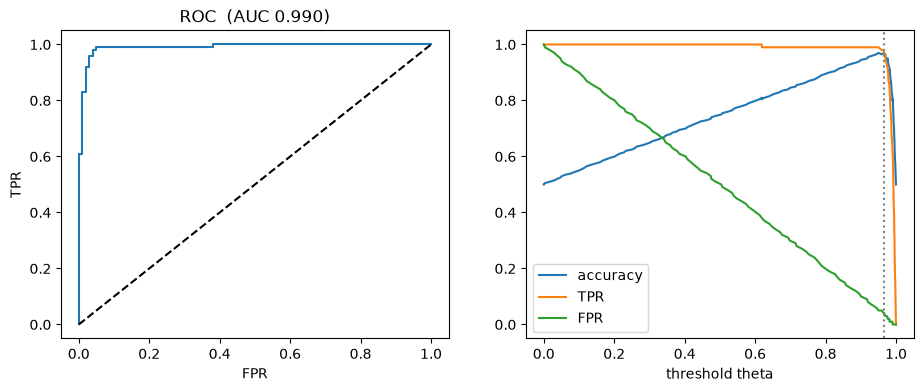

In [ ]:
# 5a - ROC / AUC / optimal cut-off from (true label, predicted probability)
d = np.loadtxt("soft-classifications-1.csv", delimiter=",", skiprows=1)
y, p = d[:, 0], d[:, 1]
P, N = (y == 1).sum(), (y == 0).sum()

th = np.r_[1.0, np.unique(p)[::-1], 0.0]  # sweep every distinct probability as threshold
TPR = np.array([np.sum(p[y == 1] >= t) for t in th]) / P
FPR = np.array([np.sum(p[y == 0] >= t) for t in th]) / N
ACC = np.array([np.mean((p >= t) == y) for t in th])

auc = np.trapezoid(TPR, FPR)
cut = th[np.argmax(TPR - FPR)]  # Youden's J: point furthest above the diagonal
print(f"AUC {auc:.3f}   best threshold {cut:.3f}   accuracy@0.5 {np.mean((p >= 0.5) == y):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(FPR, TPR); ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set(xlabel="FPR", ylabel="TPR", title=f"ROC  (AUC {auc:.3f})")
ax[1].plot(th, ACC, label="accuracy"); ax[1].plot(th, TPR, label="TPR"); ax[1].plot(th, FPR, label="FPR")
ax[1].axvline(cut, color="grey", ls=":"); ax[1].set(xlabel="threshold theta"); ax[1].legend()
plt.show()

### (5b) Reading the plots

**`soft-classifications-1.csv` — 200 points, perfectly balanced (100 positives / 100 negatives).**

- **Ranking quality is excellent: AUC $\approx 0.99$.** The ROC curve almost reaches the
  top-left corner: there is an operating point with TPR $\approx 0.98$ at FPR $\approx 0.04$.
  Ordered by predicted probability, positives and negatives are almost perfectly separated,
  so as a *ranker* this classifier is very good.
- **But the probability scale is shifted.** Positives are scored very confidently
  (mean $\hat p \approx 0.99$, all above $0.62$), whereas negatives are spread across the
  whole range (median $\hat p \approx 0.50$, up to $\approx 0.99$). About half the negatives
  sit above $0.5$.
- **Consequence for the threshold.** Accuracy climbs steadily as $\theta$ increases —
  from $\approx 0.55$ near $\theta=0$, through $\approx 0.75$ at the **default $\theta=0.5$**
  (there FPR $\approx 0.5$: half the negatives are false positives), up to a plateau of
  $\approx 0.96\text{–}0.97$ for $\theta\in[0.90,\,0.97]$, and then it collapses for
  $\theta\gtrsim 0.97$ as true positives start to be cut. TPR stays $\approx 1$ until
  $\theta\approx 0.97$, then drops fast.
- **Optimal cut-off.** Youden's $J$ gives $\theta^\star\approx 0.965$
  (TPR $\approx 0.98$, FPR $\approx 0.04$, accuracy $\approx 0.97$) — the ROC point closest
  to the top-left corner.
- **Verdict.** A *good* classifier in the threshold-independent sense (high AUC, ROC hugging
  the corner), but it must **not** be used at the default $0.5$, where accuracy is only
  $\approx 0.75$; the decision threshold has to be raised to $\approx 0.96$. This is exactly
  the point of L4 slide 8: accuracy at a fixed threshold can badly understate a classifier
  whose ranking is strong, so AUC and the ROC curve are the fairer summary.

*(With more `soft-classifications-#.csv` files the same function gives one ROC / AUC per
classifier: AUC near $1$ with a corner-hugging ROC = good; a curve on the diagonal with
AUC $\approx 0.5$ = no better than random; AUC $< 0.5$ = systematically inverted, so
flipping its predictions would help. A classifier whose accuracy peaks only in a thin
slice of $\theta$ is very sensitive to the threshold choice.)*